## Setup

Mount Drive and create the project folders.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

PROJECT = Path('/content/drive/MyDrive/derm9')

NOTEBOOKS   = PROJECT / 'notebooks'
DATA        = PROJECT / 'data'
FIGURES     = PROJECT / 'figures'
CHECKPOINTS = PROJECT / 'checkpoints'

# Safe to re-run; existing folders aren't touched.
for folder in [NOTEBOOKS, DATA, FIGURES, CHECKPOINTS]:
    folder.mkdir(parents=True, exist_ok=True)

print('Project root :', PROJECT)
print('Notebooks    :', NOTEBOOKS)
print('Data         :', DATA)
print('Figures      :', FIGURES)
print('Checkpoints  :', CHECKPOINTS)

Mounted at /content/drive
Project root : /content/drive/MyDrive/derm9
Notebooks    : /content/drive/MyDrive/derm9/notebooks
Data         : /content/drive/MyDrive/derm9/data
Figures      : /content/drive/MyDrive/derm9/figures
Checkpoints  : /content/drive/MyDrive/derm9/checkpoints


## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision.transforms import v2

# A single seed so sample images, augmented previews, etc. are reproducible.
SEED = 99
np.random.seed(SEED)
torch.manual_seed(SEED)

## Download the dataset

In [ ]:
import kagglehub
import shutil

path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")

if not any(DATA.iterdir()):
    print('Copying to Drive...')
    shutil.copytree(path, DATA, dirs_exist_ok=True)
    print('Done. Data is at:', DATA)
else:
    print('Drive already has data, skipping copy.')

100%|██████████| 786M/786M [00:30<00:00, 26.7MB/s]

Extracting files...


Copying to Drive...
Done. Data is at: /content/drive/MyDrive/derm9/data


In [ ]:
# Sanity-check: count all .jpg files under DATA and peek at the directory layout.
all_images = list(DATA.rglob('*.jpg'))
print(f'Total .jpg files found: {len(all_images):,}')
print(f'Example path: {all_images[0]}')
print()
print(f'Top-level contents of {DATA}:')
for p in sorted(DATA.iterdir()):
    print(f'  {p.name}')

Total .jpg files found: 2,357
Example path: /content/drive/MyDrive/derm9/data/Skin cancer ISIC The International Skin Imaging Collaboration/Train/actinic keratosis/ISIC_0028820.jpg

Top-level contents of /content/drive/MyDrive/derm9/data:
  Skin cancer ISIC The International Skin Imaging Collaboration


## Build a metadata DataFrame

Turn the file system into a table; one row per image, with columns for the split, the class label, the filename, and the full path. From here on, the DataFrame is the single source of truth.



In [ ]:
def load_metadata(data_dir: Path) -> pd.DataFrame:
    """Walk the dataset tree and build one row per image."""
    rows = []
    for path in data_dir.rglob('*.jpg'):
        # The last three path parts are always (split, class, filename),
        # regardless of how deep the wrapper folder nests them.
        split, cls, fname = path.parts[-3:]
        rows.append({
            'split_orig': split.lower(),
            'class_orig': cls,
            'image':      fname,
            'filepath':   str(path),
        })
    return pd.DataFrame(rows)

df = load_metadata(DATA)
print(f'Rows: {len(df):,}')
df.sample(7)

Rows: 2,357


,split_orig,class_orig,image,filepath
386,train,squamous cell carcinoma,ISIC_0025831.jpg,/content/drive/MyDrive/derm9/data/Skin cancer ...
574,train,nevus,ISIC_0000424.jpg,/content/drive/MyDrive/derm9/data/Skin cancer ...
329,train,vascular lesion,ISIC_0024867.jpg,/content/drive/MyDrive/derm9/data/Skin cancer ...
2193,train,melanoma,ISIC_0010171.jpg,/content/drive/MyDrive/derm9/data/Skin cancer ...
2105,train,melanoma,ISIC_0009910.jpg,/content/drive/MyDrive/derm9/data/Skin cancer ...
1120,train,pigmented benign keratosis,ISIC_0028611.jpg,/content/drive/MyDrive/derm9/data/Skin cancer ...
2303,test,nevus,ISIC_0000001.jpg,/content/drive/MyDrive/derm9/data/Skin cancer ...


## Class distribution



In [ ]:
# margins=True adds row and column totals, which makes the imbalance
# obvious at a glance.
counts = pd.crosstab(df['class_orig'], df['split_orig'], margins=True)
print(counts)

split_orig                  test  train   All
class_orig                                   
actinic keratosis             16    114   130
basal cell carcinoma          16    376   392
dermatofibroma                16     95   111
melanoma                      16    438   454
nevus                         16    357   373
pigmented benign keratosis    16    462   478
seborrheic keratosis           3     77    80
squamous cell carcinoma       16    181   197
vascular lesion                3    139   142
All                          118   2239  2357


Heavy imbalance; pigmented benign keratosis has roughly 6× the images of seborrheic keratosis. Test set is uniformly 16 per class for most classes but only 3 for two of them, which is too thin to evaluate those classes reliably.

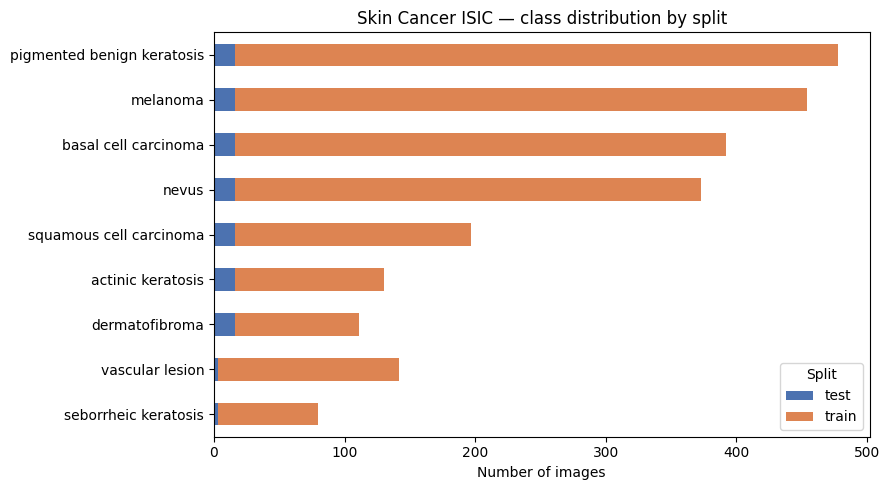

In [ ]:
# Visualize as a horizontal stacked bar chart, smallest class at the bottom.
plot_df = counts.drop('All', axis=0).drop('All', axis=1).sort_values(
    by=list(counts.columns[:-1]), ascending=True
)

ax = plot_df.plot.barh(stacked=True, figsize=(9, 5),
                       color=['#4c72b0', '#dd8452'])
ax.set_xlabel('Number of images')
ax.set_ylabel('')
ax.set_title('Skin Cancer ISIC — class distribution by split')
ax.legend(title='Split', loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Preview images per class


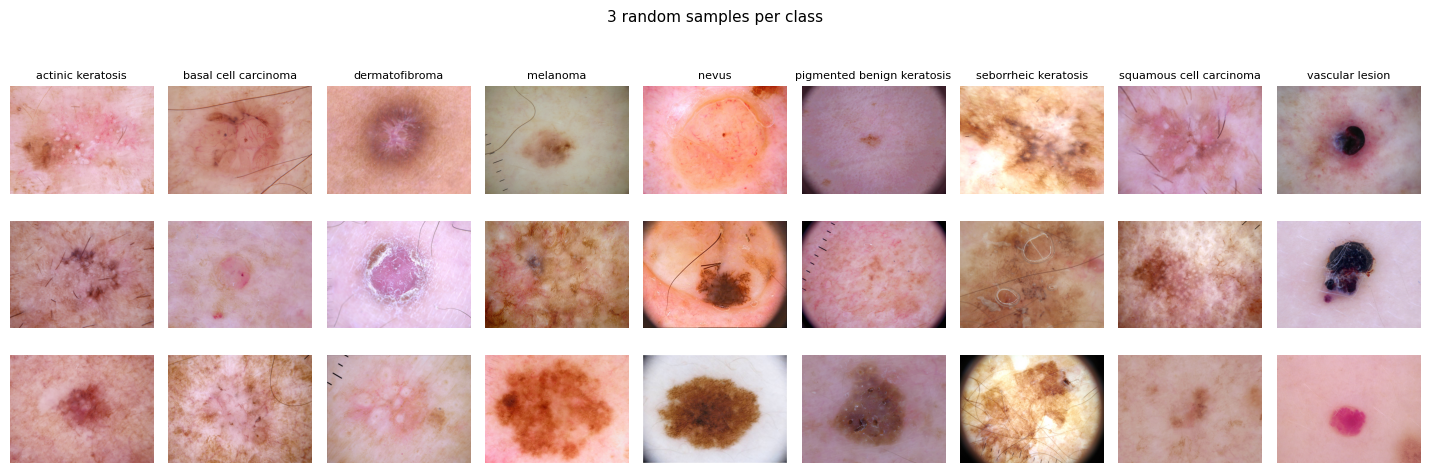

In [ ]:
classes = sorted(df['class_orig'].unique())
n_per_class = 3

# Flipped: classes become columns, samples become rows.
fig, axes = plt.subplots(n_per_class, len(classes),
                         figsize=(1.6 * len(classes), 1.6 * n_per_class))

for col, cls in enumerate(classes):
    samples = df[df['class_orig'] == cls].sample(n_per_class, random_state=SEED)
    for row, (_, sample) in enumerate(samples.iterrows()):
        ax = axes[row, col]
        ax.imshow(Image.open(sample['filepath']))
        ax.axis('off')
        # Title above each column, only on the top row.
        if row == 0:
            ax.set_title(cls, fontsize=8, wrap=True)

plt.suptitle(f'{n_per_class} random samples per class', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

Each column shows three random samples from one class. Within a column the lesions belong to the same category but vary in appearance. Across columns, some classes look visually similar to each other while others stand apart.

## Augmentation preview


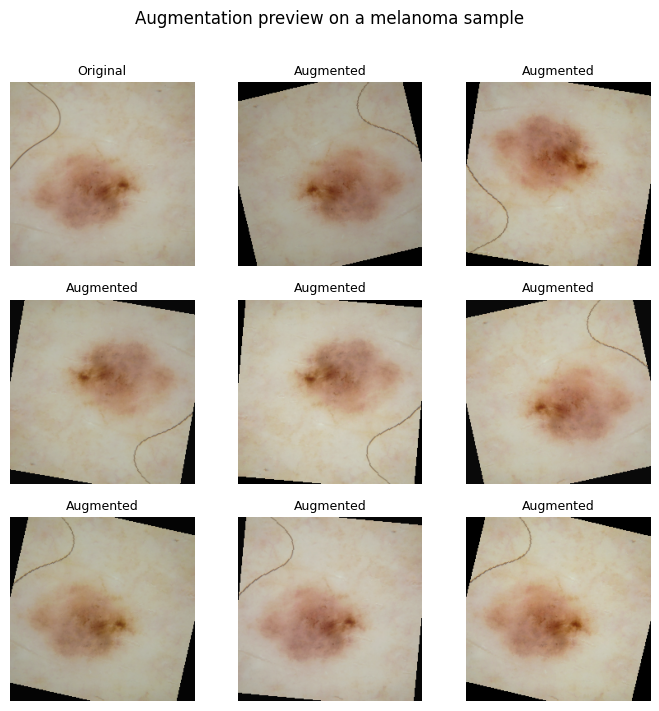

In [ ]:
from torchvision.transforms import v2

preview_aug = v2.Compose([
    v2.Resize(size=256, antialias=True),
    v2.CenterCrop(size=224),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=15),
    v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
])

# Pick one melanoma image .
sample_path = df.loc[df['class_orig'] == 'melanoma', 'filepath'].sample(
    1, random_state=SEED
).values[0]
sample_img = Image.open(sample_path).convert('RGB')

# Resize+crop the original too so all 9 panels match in size.
base_tfm = v2.Compose([v2.Resize(256, antialias=True), v2.CenterCrop(224)])

torch.manual_seed(SEED)

fig, axes = plt.subplots(3, 3, figsize=(7, 7))
axes = axes.flatten()

axes[0].imshow(base_tfm(sample_img))
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

for ax in axes[1:]:
    ax.imshow(preview_aug(sample_img))
    ax.set_title('Augmented', fontsize=9)
    ax.axis('off')

plt.suptitle('Augmentation preview on a melanoma sample', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'augmentation_preview.png', dpi=100, bbox_inches='tight')
plt.show()

## Save the curated metadata

In [ ]:
out_path = DATA / 'derm9_curated.csv'

(df[['image', 'filepath', 'class_orig', 'split_orig']]
   .sort_values(['class_orig', 'image'])
   .reset_index(drop=True)
   .to_csv(out_path, index=False))

print(f'Saved: {out_path}')
print(f'  size: {out_path.stat().st_size / 1e6:.2f} MB')
print(f'  rows: {len(df):,}')

Saved: /content/drive/MyDrive/derm9/data/derm9_curated.csv
  size: 0.41 MB
  rows: 2,357
